# Problem 1

We wish to numerically solve the set of differential equations: 

$$ H^2 = \left(\frac{\dot R}{R}\right)^2 = \frac{8\pi G}{3}\rho\text{, and}$$

$$ \dot H + H^2 = \frac{\ddot R}{R} = -\frac{4\pi G}{3}(1+3w)\rho\text{ with}$$

$$ \dot\rho = -3H(1+w)\rho $$

First, we will analytically solve them. We do so by combing al of the given equations.

Note that
$$ H = \sqrt{\frac{8\pi G}{3}}\rho^{1/2}. $$

We can combine the first and the third equation to find

$$ \dot\rho = -3\sqrt{\frac{8\pi G}{3}}(1+w)\rho^{3/2} = \sqrt{24\pi G} (1+w)\rho^{3/2}$$

This allows us to find a closed form solution for $\rho$.
$$ \rho^{-3/2}d\rho = \sqrt{24\pi G} (1+w)dt  \longrightarrow -2\rho^{-1/2} - 2\rho_0^{-1/2} = \sqrt{24\pi G} (1+w) (t-t_0) \longrightarrow \boxed{\rho = \left(\frac{1}{\sqrt{6\pi G} (1+w) (t-t_0) + \rho_0^{-1/2}}\right)^2}$$

Now we can plug this into $\dot R $

$$\frac{\dot R}{R} = \sqrt{\frac{8\pi G}{3}}\left(\frac{1}{\sqrt{6\pi G} (1+w) (t-t_0) + \rho_0^{-1/2}}\right) $$

We let $A = \sqrt{6\pi G} (1+w)$ and we find 

$$ \frac{1}{R}dR = \sqrt{\frac{8\pi G}{3}}\left(\frac{1}{A (t-t_0) + \rho_0^{-1/2}}\right)dt$$

This is a rather straightforward integral. We use $\int \frac{1}{ax+b}dx = \frac{1}{a}ln|ax+b|$.
$$ \ln\left(\frac{R}{R_0}\right) = \sqrt{\frac{8\pi G}{3}}\int_{0}^{t-t_0}\frac{1}{A t + \rho_0^{-1/2}}dt = \frac{1}{A}\sqrt{\frac{8\pi G}{3}}\ln|A t + \rho_0^{-1/2}|_0^{t-t_0}$$

$$\ln\left(\frac{R}{R_0}\right) = \frac{1}{1+w}\frac{2}{3}\ln\left(A(t-t_0)\rho_0^{1/2} + 1\right)$$

This gives the (kind of ugly) solution:
$$\frac{R}{R_0} = e^{\frac{1}{1+w}\frac{2}{3}\ln\left(A(t-t_0)\rho_0^{1/2} + 1\right)} = \left(A(t-t_0)\rho_0^{1/2} + 1\right)^{\frac{1}{1+w}\frac{2}{3}} = \left(\sqrt{6\pi G} (1+w)(t-t_0)\rho_0^{1/2} + 1\right)^{\frac{1}{1+w}\frac{2}{3}}$$

$$\boxed{R = R_0\left(\sqrt{6\pi G} (1+w)(t-t_0)\rho_0^{1/2} + 1\right)^{\frac{1}{1+w}\frac{2}{3}}}$$

In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams['legend.fancybox'] = True
import matplotlib.pyplot as plt
import scipy.integrate
import scipy.optimize

In [2]:
params_GR = {
    'tau': 0.01,
    'accuracy': 1e-6,
    'G': 1.0,               #Gravitational Constant
    'w': 1,                 #Equation of state parameter
    'R0': 1,                #Initial scale factor
    'rho0': 1,              #Initial density
    'step_using_y': False,
    'method': 'RK45',
    'tmax': 4.,
}

In [3]:
class GHard :
    def __init__( self, params ):
        self.params=params
        for iparam,param in params.items():
            setattr(self, iparam, params[iparam])
    
    def set_param(self, parname, parval ):
        setattr( self, parname, parval )
        
    def __call__(self, t, p ) :
        R = p[0]
        rho = p[1]
        H = np.sqrt((8*np.pi*self.G/3)*rho)
        
        Rdot = p[2]
        rhodot = -3*H*(1 + self.w)*rho 
        
        Rddot = -4*np.pi*self.G*(1+3*self.w)*rho*R
        
        flow = np.array([ Rdot, rhodot, Rddot ])
        return flow

In [4]:
ghard = GHard(params_GR)
wlist = [-1/3, -0.2, -0.1, -0.05, -0.01, 0, 0.01, 0.05, 0.1, 0.2, 1/3, 2/3, 1]
Rdot0 = ghard.R0*np.sqrt(8*np.pi*ghard.G*ghard.rho0/3)

results = []
for i in wlist:
    ghard.set_param('w', i)
    res = scipy.integrate.solve_ivp(fun=ghard,t_span=(0,ghard.tmax),
                                y0=[ghard.R0, ghard.rho0, Rdot0], 
                                vectorized=True,
                                atol=1e-8,rtol=1e-6,
                                method=ghard.method,
                                first_step = 0.001)
    results.append(res)


tlist = [res.t for res in results]
states= [res.y for res in results]
Rlist = [state[0] for state in states]
rholist = [state[1] for state in states]

Before we plot the numerical results, let's make some functions to plot our analytical results too.

In [5]:
def R_analyt(t, w, R0, G, t0, rho0):
    return R0*(np.sqrt(6*np.pi*G)*(1+w)*(t-t0)*rho0**0.5 + 1)**(2/(3*(1+w)))

def rho_analyt(t, w, G, t0, rho0):
    return (np.sqrt(6*np.pi*G)*(1+w)*(t-t0) + rho0**(-0.5))**(-2)

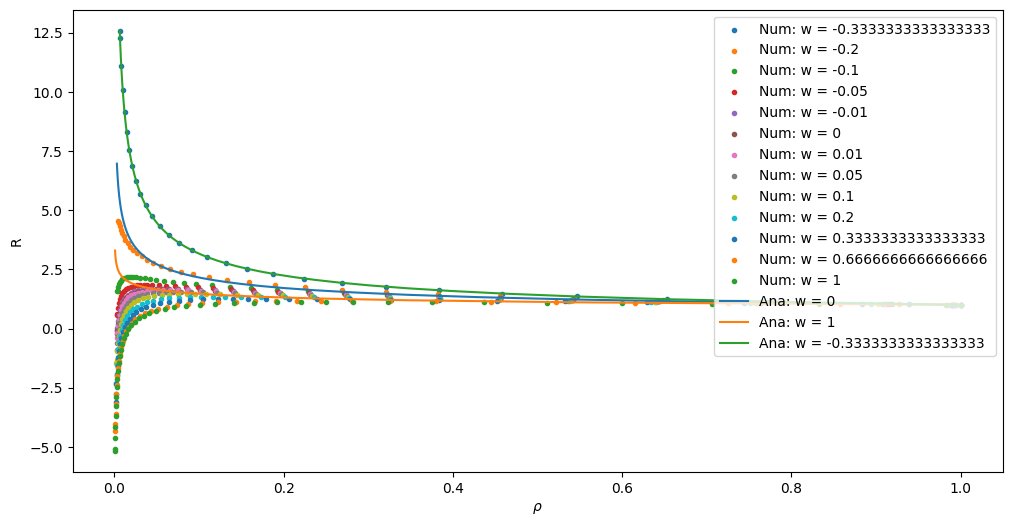

In [6]:

fig = plt.figure(1,figsize=(12,6))

for i, R in enumerate(Rlist):
    plt.scatter(rholist[i] ,R, marker = '.', label = f'Num: w = {wlist[i]}')

wlist_analyt = [0,1,-1/3]
t = np.linspace(0,ghard.tmax,100)

for i, w in enumerate(wlist_analyt):
    plt.plot(rho_analyt(t, w, ghard.G, 0, ghard.rho0), R_analyt(t, w, ghard.R0, ghard.G, 0, ghard.rho0), label = f'Ana: w = {wlist_analyt[i]}')
        
plt.ylabel('R')
plt.xlabel(r'$\rho$')
plt.legend()

# Time Plots

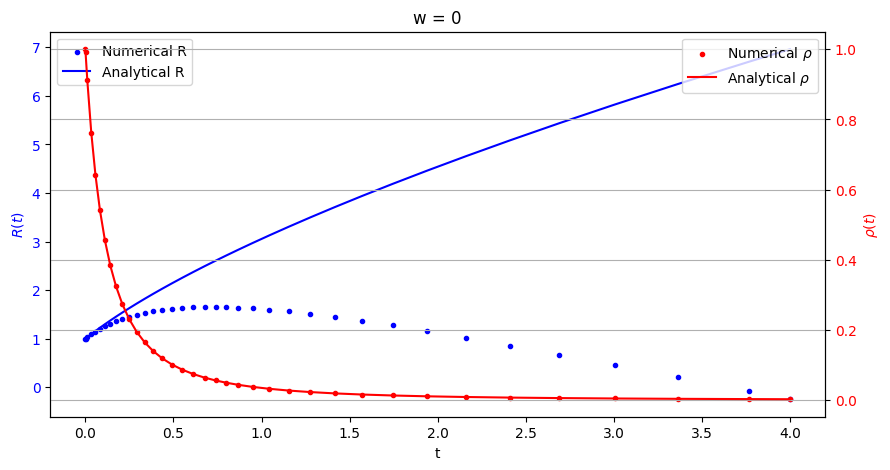

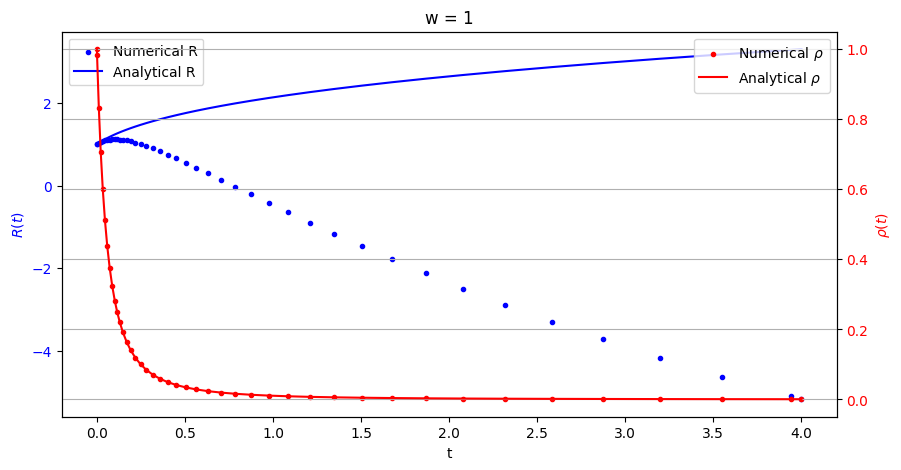

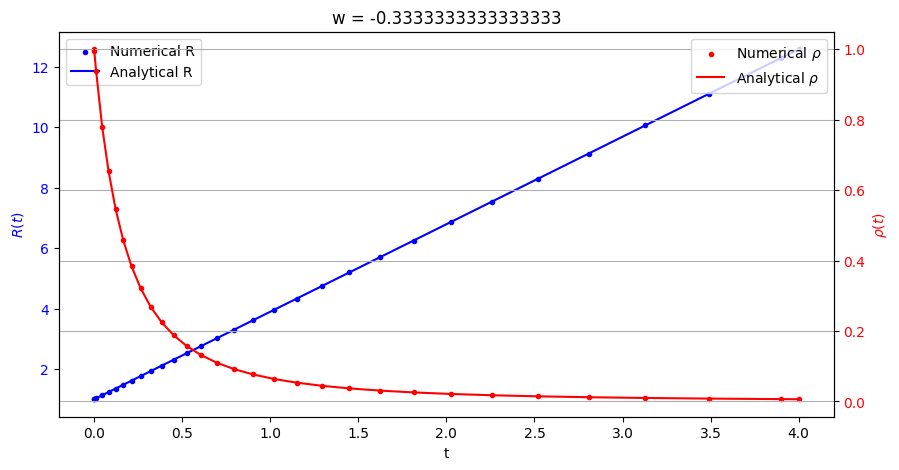

'\nax1.scatter(self.x, np.abs(self.psi), label=r"$|\\psi(x)|$", color="b")\nax1.set_xlabel("x")\nax1.set_ylabel(r"$|\\psi(x)|$", color="b")\nax1.tick_params(axis="y", labelcolor="b")\n\nax2 = ax1.twinx()\nax2.plot(self.x, V_x, label="Kronig-Penney Potential", color="r", linestyle="--")\nax2.set_ylabel("V(x)", color="r")\nax2.tick_params(axis="y", labelcolor="r")\n\nax1.legend(loc="upper right")\nax2.legend(loc="upper left")\nplt.title("Wavepacket and Kronig-Penney Potential")\nplt.grid()\nplt.show()\n'

In [7]:
wlist = [0,1,-1/3]

results = []
for i in wlist:
    ghard.set_param('w', i)
    res = scipy.integrate.solve_ivp(fun=ghard,t_span=(0,ghard.tmax),
                                y0=[ghard.R0, ghard.rho0, Rdot0], 
                                vectorized=True,
                                atol=1e-8,rtol=1e-6,
                                method=ghard.method,
                                first_step = 0.001)
    results.append(res)


tlist = [res.t for res in results]
states= [res.y for res in results]
Rlist = [state[0] for state in states]
rholist = [state[1] for state in states]

for i, R in enumerate(Rlist):
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.scatter(tlist[i] ,R, marker = '.',color="b", label = f'Numerical R')
    ax1.plot(tlist[i], R_analyt(tlist[i], wlist[i], ghard.R0, ghard.G, 0, ghard.rho0), color="b", label = f'Analytical R')
    ax1.set_xlabel("t")
    ax1.set_ylabel(r"$R(t)$", color="b")
    ax1.tick_params(axis="y", labelcolor="b")
    
    ax2 = ax1.twinx()
    ax2.scatter(tlist[i] , rholist[i], marker = '.', color="r", label = f'Numerical $\\rho$')
    ax2.plot(tlist[i], rho_analyt(tlist[i], wlist[i], ghard.G, 0, ghard.rho0), color="r", label = f'Analytical $\\rho$')
    ax2.set_ylabel(r"$\rho(t)$", color="r")
    ax2.tick_params(axis="y", labelcolor="r")
    
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title(f"w = {wlist[i]}")
    plt.grid()
    plt.show()

'''
ax1.scatter(self.x, np.abs(self.psi), label=r"$|\psi(x)|$", color="b")
ax1.set_xlabel("x")
ax1.set_ylabel(r"$|\psi(x)|$", color="b")
ax1.tick_params(axis="y", labelcolor="b")

ax2 = ax1.twinx()
ax2.plot(self.x, V_x, label="Kronig-Penney Potential", color="r", linestyle="--")
ax2.set_ylabel("V(x)", color="r")
ax2.tick_params(axis="y", labelcolor="r")

ax1.legend(loc="upper right")
ax2.legend(loc="upper left")
plt.title("Wavepacket and Kronig-Penney Potential")
plt.grid()
plt.show()
'''